In [165]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Crear carpeta de salida
os.makedirs("output", exist_ok=True)

ruta = 'data/ExtraccionERP.csv'
df = pd.read_csv(ruta, sep=";")
df.head()

,ID venta,ID pedido,Fecha del pedido,Días de envío programado,Fecha de envío,Días de envío real,Retrasado,Estado del pedido,Estado de entrega,Tipo transaccion,...,Nombre de categoría,ID seccion,Nombre de seccion,ID cliente,Segmento del cliente,Latitud,Longitud,Ciudad del cliente,Estado del cliente,País del cliente
0,1.0,1.0,01/01/2021 0:00,4.0,03/01/2021 0:00,2.0,0.0,CLOSED,Advance shipping,CASH,...,Camping & Hiking,7.0,Fan Shop,11599.0,Consumer,"35,77666092","-81,36262512",Hickory,NC,EE. UU.
1,2.0,2.0,01/01/2021 0:21,4.0,04/01/2021 0:21,3.0,0.0,PENDING_PAYMENT,Advance shipping,PAYMENT,...,Water Sports,7.0,Fan Shop,256.0,Consumer,"41,83272171","-87,98048401",Chicago,IL,EE. UU.
2,3.0,2.0,01/01/2021 0:21,4.0,04/01/2021 0:21,3.0,0.0,PENDING_PAYMENT,Advance shipping,PAYMENT,...,Women's Apparel,5.0,Golf,256.0,Consumer,"41,83272171","-87,98048401",Chicago,IL,EE. UU.
3,4.0,2.0,01/01/2021 0:21,4.0,04/01/2021 0:21,3.0,0.0,PENDING_PAYMENT,Advance shipping,PAYMENT,...,Men's Footwear,4.0,Apparel,256.0,Consumer,"41,83272171","-87,98048401",Chicago,IL,EE. UU.
4,5.0,4.0,01/01/2021 1:03,4.0,06/01/2021 1:03,5.0,1.0,CLOSED,Late delivery,CASH,...,Accessories,6.0,Outdoors,8827.0,Home Office,"29,52001","-98,63741303",San Antonio,TX,EE. UU.


In [166]:
print("Dimensiones (filas, columnas):", df.shape)
print("\nTipos de datos:\n")
df.info()

Dimensiones (filas, columnas): (166777, 32)

Tipos de datos:

<class 'pandas.DataFrame'>
RangeIndex: 166777 entries, 0 to 166776
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0    ID venta                   166773 non-null  float64
 1    ID pedido                  166773 non-null  float64
 2    Fecha del pedido           166773 non-null  str    
 3    Días de envío programado   166773 non-null  float64
 4    Fecha de envío             166773 non-null  str    
 5    Días de envío real         166773 non-null  float64
 6   Retrasado                   166773 non-null  float64
 7    Estado del pedido          166773 non-null  str    
 8    Estado de entrega          166773 non-null  str    
 9   Tipo transaccion            166773 non-null  str    
 10   Modo de envío              166773 non-null  str    
 11   ID producto                166773 non-null  float64
 12   Nombre del producto 

In [ ]:
df = df.sample(n=30000, random_state=42)

# Estandarización de nombres de variables para facilitar su manipulación y análisis, eliminando caracteres especiales y aplicando un formato homogéneo en mayúsculas con guiones bajos.
df.columns = [
    'ID_VENTA',
    'ID_PEDIDO',
    'FECHA_PEDIDO',
    'DIAS_ENVIO_PROGRAMADO',
    'FECHA_ENVIO',
    'DIAS_ENVIO_REAL',
    'RETRASADO',
    'ESTADO_PEDIDO',
    'ESTADO_ENTREGA',
    'TIPO_TRANSACCION',
    'MODO_ENVIO',
    'ID_PRODUCTO',
    'NOMBRE_PRODUCTO',
    'PRECIO_PRODUCTO',
    'CANTIDAD',
    'PRECIO_TOTAL_SIN_DESCUENTO',
    'TASA_DESCUENTO',
    'DESCUENTO',
    'PRECIO_TOTAL_CON_DESCUENTO',
    'MARGEN_PORCENTAJE',
    'MARGEN_DOLARES',
    'ID_CATEGORIA',
    'NOMBRE_CATEGORIA',
    'ID_SECCION',
    'NOMBRE_SECCION',
    'ID_CLIENTE',
    'SEGMENTO_CLIENTE',
    'LATITUD',
    'LONGITUD',
    'CIUDAD_CLIENTE',
    'ESTADO_CLIENTE',
    'PAIS_CLIENTE'
]

df = df.drop(columns=["ID_VENTA"], errors="ignore")

cols_numericas = [
    'PRECIO_PRODUCTO',
    'PRECIO_TOTAL_SIN_DESCUENTO',
    'TASA_DESCUENTO',
    'DESCUENTO',
    'PRECIO_TOTAL_CON_DESCUENTO',
    'MARGEN_PORCENTAJE',
    'MARGEN_DOLARES',
    'LATITUD',
    'LONGITUD'
]

for col in cols_numericas:
    df[col] = df[col].str.replace(',', '.')
    df[col] = df[col].str.replace('%', '')
    df[col] = df[col].str.replace('$', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['FECHA_PEDIDO'] = pd.to_datetime(
    df['FECHA_PEDIDO'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)

df['FECHA_ENVIO'] = pd.to_datetime(
    df['FECHA_ENVIO'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)

df.to_csv("data/ExtraccionERP_limpio.csv", index=False)

print("Dimensiones (filas, columnas):", df.shape)
print("\nTipos de datos:\n")
df.info()

Dimensiones (filas, columnas): (30000, 31)

Tipos de datos:

<class 'pandas.DataFrame'>
Index: 30000 entries, 27470 to 10195
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ID_PEDIDO                   30000 non-null  float64       
 1   FECHA_PEDIDO                30000 non-null  datetime64[us]
 2   DIAS_ENVIO_PROGRAMADO       30000 non-null  float64       
 3   FECHA_ENVIO                 30000 non-null  datetime64[us]
 4   DIAS_ENVIO_REAL             30000 non-null  float64       
 5   RETRASADO                   30000 non-null  float64       
 6   ESTADO_PEDIDO               30000 non-null  str           
 7   ESTADO_ENTREGA              30000 non-null  str           
 8   TIPO_TRANSACCION            30000 non-null  str           
 9   MODO_ENVIO                  30000 non-null  str           
 10  ID_PRODUCTO                 30000 non-null  float64       
 11  NOMBR

In [168]:
print("Dimensiones (filas, columnas):", df.shape)

memoria_bytes = df.memory_usage(deep=True).sum()
memoria_mb = memoria_bytes / (1024 ** 2)

print(f"Tamaño en memoria: {memoria_bytes} bytes")
print(f"Tamaño en memoria: {memoria_mb:.4f} MB")

Dimensiones (filas, columnas): (30000, 31)
Tamaño en memoria: 24987416 bytes
Tamaño en memoria: 23.8299 MB


In [169]:
target = "MARGEN_DOLARES"
print("Variable objetivo:", target)

columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_numericas = [
    col for col in columnas_numericas if not col.startswith("ID_")
]
columnas_categoricas = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()

print("\nColumnas numéricas:", columnas_numericas)
print("Columnas categóricas:", columnas_categoricas)

Variable objetivo: MARGEN_DOLARES

Columnas numéricas: ['DIAS_ENVIO_PROGRAMADO', 'DIAS_ENVIO_REAL', 'RETRASADO', 'PRECIO_PRODUCTO', 'CANTIDAD', 'PRECIO_TOTAL_SIN_DESCUENTO', 'TASA_DESCUENTO', 'DESCUENTO', 'PRECIO_TOTAL_CON_DESCUENTO', 'MARGEN_PORCENTAJE', 'MARGEN_DOLARES', 'LATITUD', 'LONGITUD']
Columnas categóricas: ['ESTADO_PEDIDO', 'ESTADO_ENTREGA', 'TIPO_TRANSACCION', 'MODO_ENVIO', 'NOMBRE_PRODUCTO', 'NOMBRE_CATEGORIA', 'NOMBRE_SECCION', 'SEGMENTO_CLIENTE', 'CIUDAD_CLIENTE', 'ESTADO_CLIENTE', 'PAIS_CLIENTE']


In [170]:
# Vemos que variables numéricas peuden ser categoricas, por ejemplo tienen 0/1
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

ID_PEDIDO: 23680 valores únicos
FECHA_PEDIDO: 23680 valores únicos
DIAS_ENVIO_PROGRAMADO: 4 valores únicos
FECHA_ENVIO: 23373 valores únicos
DIAS_ENVIO_REAL: 7 valores únicos
RETRASADO: 2 valores únicos
ESTADO_PEDIDO: 9 valores únicos
ESTADO_ENTREGA: 4 valores únicos
TIPO_TRANSACCION: 4 valores únicos
MODO_ENVIO: 4 valores únicos
ID_PRODUCTO: 87 valores únicos
NOMBRE_PRODUCTO: 87 valores únicos
PRECIO_PRODUCTO: 50 valores únicos
CANTIDAD: 5 valores únicos
PRECIO_TOTAL_SIN_DESCUENTO: 165 valores únicos
TASA_DESCUENTO: 18 valores únicos
DESCUENTO: 526 valores únicos
PRECIO_TOTAL_CON_DESCUENTO: 1629 valores únicos
MARGEN_PORCENTAJE: 161 valores únicos
MARGEN_DOLARES: 10189 valores únicos
ID_CATEGORIA: 32 valores únicos
NOMBRE_CATEGORIA: 31 valores únicos
ID_SECCION: 6 valores únicos
NOMBRE_SECCION: 6 valores únicos
ID_CLIENTE: 10597 valores únicos
SEGMENTO_CLIENTE: 3 valores únicos
LATITUD: 7269 valores únicos
LONGITUD: 3798 valores únicos
CIUDAD_CLIENTE: 562 valores únicos
ESTADO_CLIENTE

In [171]:
df['RETRASADO'] = df['RETRASADO'].astype('category')
df.info()

<class 'pandas.DataFrame'>
Index: 30000 entries, 27470 to 10195
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ID_PEDIDO                   30000 non-null  float64       
 1   FECHA_PEDIDO                30000 non-null  datetime64[us]
 2   DIAS_ENVIO_PROGRAMADO       30000 non-null  float64       
 3   FECHA_ENVIO                 30000 non-null  datetime64[us]
 4   DIAS_ENVIO_REAL             30000 non-null  float64       
 5   RETRASADO                   30000 non-null  category      
 6   ESTADO_PEDIDO               30000 non-null  str           
 7   ESTADO_ENTREGA              30000 non-null  str           
 8   TIPO_TRANSACCION            30000 non-null  str           
 9   MODO_ENVIO                  30000 non-null  str           
 10  ID_PRODUCTO                 30000 non-null  float64       
 11  NOMBRE_PRODUCTO             30000 non-null  str           
 12  PR

In [172]:
# Hemos visto que no hay nulos
nulos_abs = df.isnull().sum()
nulos_pct = df.isnull().mean() * 100

tabla_nulos = pd.DataFrame({
    "nulos_absolutos": nulos_abs,
    "nulos_porcentaje": nulos_pct
}).sort_values(by="nulos_porcentaje", ascending=False)

tabla_nulos

,nulos_absolutos,nulos_porcentaje
ID_PEDIDO,0,0.0
FECHA_PEDIDO,0,0.0
DIAS_ENVIO_PROGRAMADO,0,0.0
FECHA_ENVIO,0,0.0
DIAS_ENVIO_REAL,0,0.0
RETRASADO,0,0.0
ESTADO_PEDIDO,0,0.0
ESTADO_ENTREGA,0,0.0
TIPO_TRANSACCION,0,0.0
MODO_ENVIO,0,0.0


In [173]:
# estadistico descriptivo
columnas_numericas = [col for col in columnas_numericas if col not in ['RETRASADO', 'LATITUD', 'LONGITUD']]
numericas_continuas = columnas_numericas
descriptivo = df[numericas_continuas].describe().T
descriptivo.to_csv("output/ej1_descriptivo.csv", encoding="utf-8")
descriptivo

,count,mean,std,min,25%,50%,75%,max
DIAS_ENVIO_PROGRAMADO,30000.0,2.926933,1.376853,0.000000,2.000000,4.000000,4.000000,4.000000
DIAS_ENVIO_REAL,30000.0,3.506133,1.631293,0.000000,2.000000,3.000000,5.000000,6.000000
PRECIO_PRODUCTO,30000.0,133.120048,117.076722,9.990000,50.000000,59.990002,199.990005,399.980011
CANTIDAD,30000.0,2.194800,1.473542,1.000000,1.000000,1.000000,3.000000,5.000000
PRECIO_TOTAL_SIN_DESCUENTO,30000.0,199.399882,111.578251,9.990000,119.980003,199.919998,299.950012,500.000000
TASA_DESCUENTO,30000.0,0.100681,0.070439,0.000000,0.040000,0.090000,0.160000,0.250000
DESCUENTO,30000.0,19.979684,19.518286,0.000000,5.500000,14.000000,28.799999,124.989998
PRECIO_TOTAL_CON_DESCUENTO,30000.0,179.420442,101.776052,7.490000,105.570000,163.979996,245.000000,499.950012
MARGEN_PORCENTAJE,30000.0,0.120275,0.466560,-2.750000,0.080000,0.270000,0.360000,0.500000
MARGEN_DOLARES,30000.0,21.171810,97.736881,-1336.369995,7.310000,31.520000,63.750000,244.979996


In [174]:
estadisticos = pd.DataFrame(index=numericas_continuas)

estadisticos["media"] = df[numericas_continuas].mean()
estadisticos["mediana"] = df[numericas_continuas].median()
estadisticos["moda"] = df[numericas_continuas].mode().iloc[0]
estadisticos["desv_tipica"] = df[numericas_continuas].std()
estadisticos["varianza"] = df[numericas_continuas].var()
estadisticos["min"] = df[numericas_continuas].min()
estadisticos["q1"] = df[numericas_continuas].quantile(0.25)
estadisticos["q2_mediana"] = df[numericas_continuas].quantile(0.50)
estadisticos["q3"] = df[numericas_continuas].quantile(0.75)
estadisticos["max"] = df[numericas_continuas].max()
estadisticos["asimetria"] = df[numericas_continuas].skew()
estadisticos["curtosis"] = df[numericas_continuas].kurtosis()

estadisticos

,media,mediana,moda,desv_tipica,varianza,min,q1,q2_mediana,q3,max,asimetria,curtosis
DIAS_ENVIO_PROGRAMADO,2.926933,4.000000,4.000000,1.376853,1.895724,0.000000,2.000000,4.000000,4.000000,4.000000,-0.726146,-1.032448
DIAS_ENVIO_REAL,3.506133,3.000000,2.000000,1.631293,2.661118,0.000000,2.000000,3.000000,5.000000,6.000000,0.069061,-1.011710
PRECIO_PRODUCTO,133.120048,59.990002,59.990002,117.076722,13706.958874,9.990000,50.000000,59.990002,199.990005,399.980011,1.250270,0.248882
CANTIDAD,2.194800,1.000000,1.000000,1.473542,2.171325,1.000000,1.000000,1.000000,3.000000,5.000000,0.794859,-0.901002
PRECIO_TOTAL_SIN_DESCUENTO,199.399882,199.919998,129.990005,111.578251,12449.706122,9.990000,119.980003,199.919998,299.950012,500.000000,0.649858,-0.351307
TASA_DESCUENTO,0.100681,0.090000,0.010000,0.070439,0.004962,0.000000,0.040000,0.090000,0.160000,0.250000,0.365229,-0.884992
DESCUENTO,19.979684,14.000000,0.000000,19.518286,380.963491,0.000000,5.500000,14.000000,28.799999,124.989998,1.560913,2.717245
PRECIO_TOTAL_CON_DESCUENTO,179.420442,163.979996,128.690002,101.776052,10358.364665,7.490000,105.570000,163.979996,245.000000,499.950012,0.698846,-0.212289
MARGEN_PORCENTAJE,0.120275,0.270000,0.480000,0.466560,0.217678,-2.750000,0.080000,0.270000,0.360000,0.500000,-2.892539,10.212133
MARGEN_DOLARES,21.171810,31.520000,0.000000,97.736881,9552.497901,-1336.369995,7.310000,31.520000,63.750000,244.979996,-3.511696,21.401017


In [175]:
q1 = df[target].quantile(0.25)
q3 = df[target].quantile(0.75)
iqr = q3 - q1

print(f"Q1 de {target}: {q1:.4f}")
print(f"Q3 de {target}: {q3:.4f}")
print(f"IQR de {target}: {iqr:.4f}")

Q1 de MARGEN_DOLARES: 7.3100
Q3 de MARGEN_DOLARES: 63.7500
IQR de MARGEN_DOLARES: 56.4400


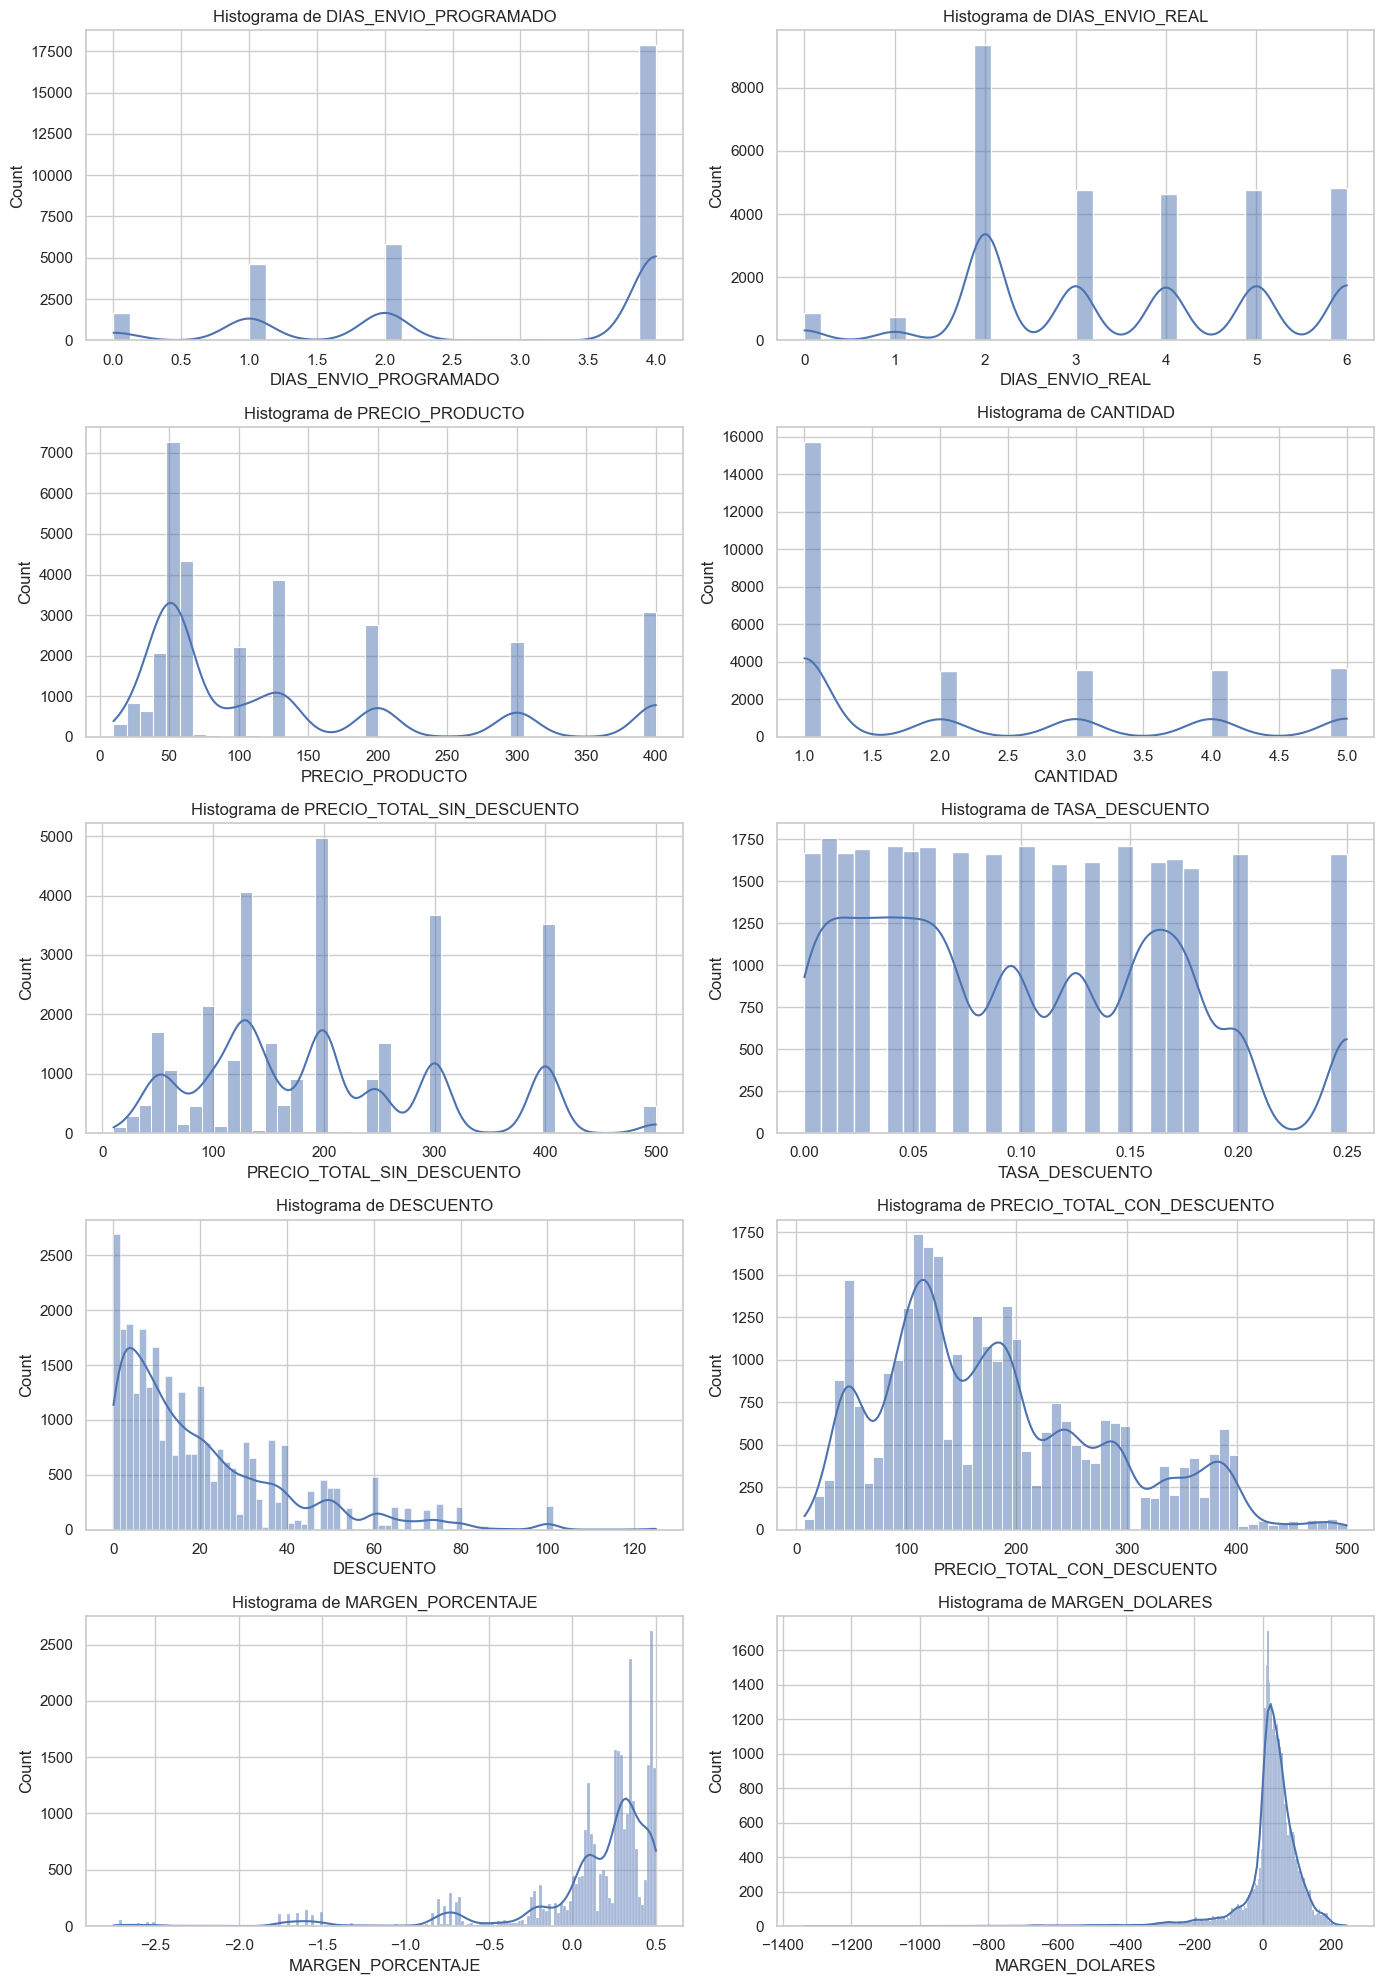

In [176]:
n = len(numericas_continuas)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numericas_continuas):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Histograma de {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("output/ej1_histogramas.png", dpi=150, bbox_inches="tight")
plt.show()

In [177]:
categoricas_reales = [col for col in columnas_categoricas if df[col].nunique() < 10]
print("Columnas categóricas:", columnas_categoricas)
print("Variables categóricas reales (con menos de 10 categorías):", categoricas_reales)

Columnas categóricas: ['ESTADO_PEDIDO', 'ESTADO_ENTREGA', 'TIPO_TRANSACCION', 'MODO_ENVIO', 'NOMBRE_PRODUCTO', 'NOMBRE_CATEGORIA', 'NOMBRE_SECCION', 'SEGMENTO_CLIENTE', 'CIUDAD_CLIENTE', 'ESTADO_CLIENTE', 'PAIS_CLIENTE']
Variables categóricas reales (con menos de 10 categorías): ['ESTADO_PEDIDO', 'ESTADO_ENTREGA', 'TIPO_TRANSACCION', 'MODO_ENVIO', 'NOMBRE_SECCION', 'SEGMENTO_CLIENTE', 'PAIS_CLIENTE']


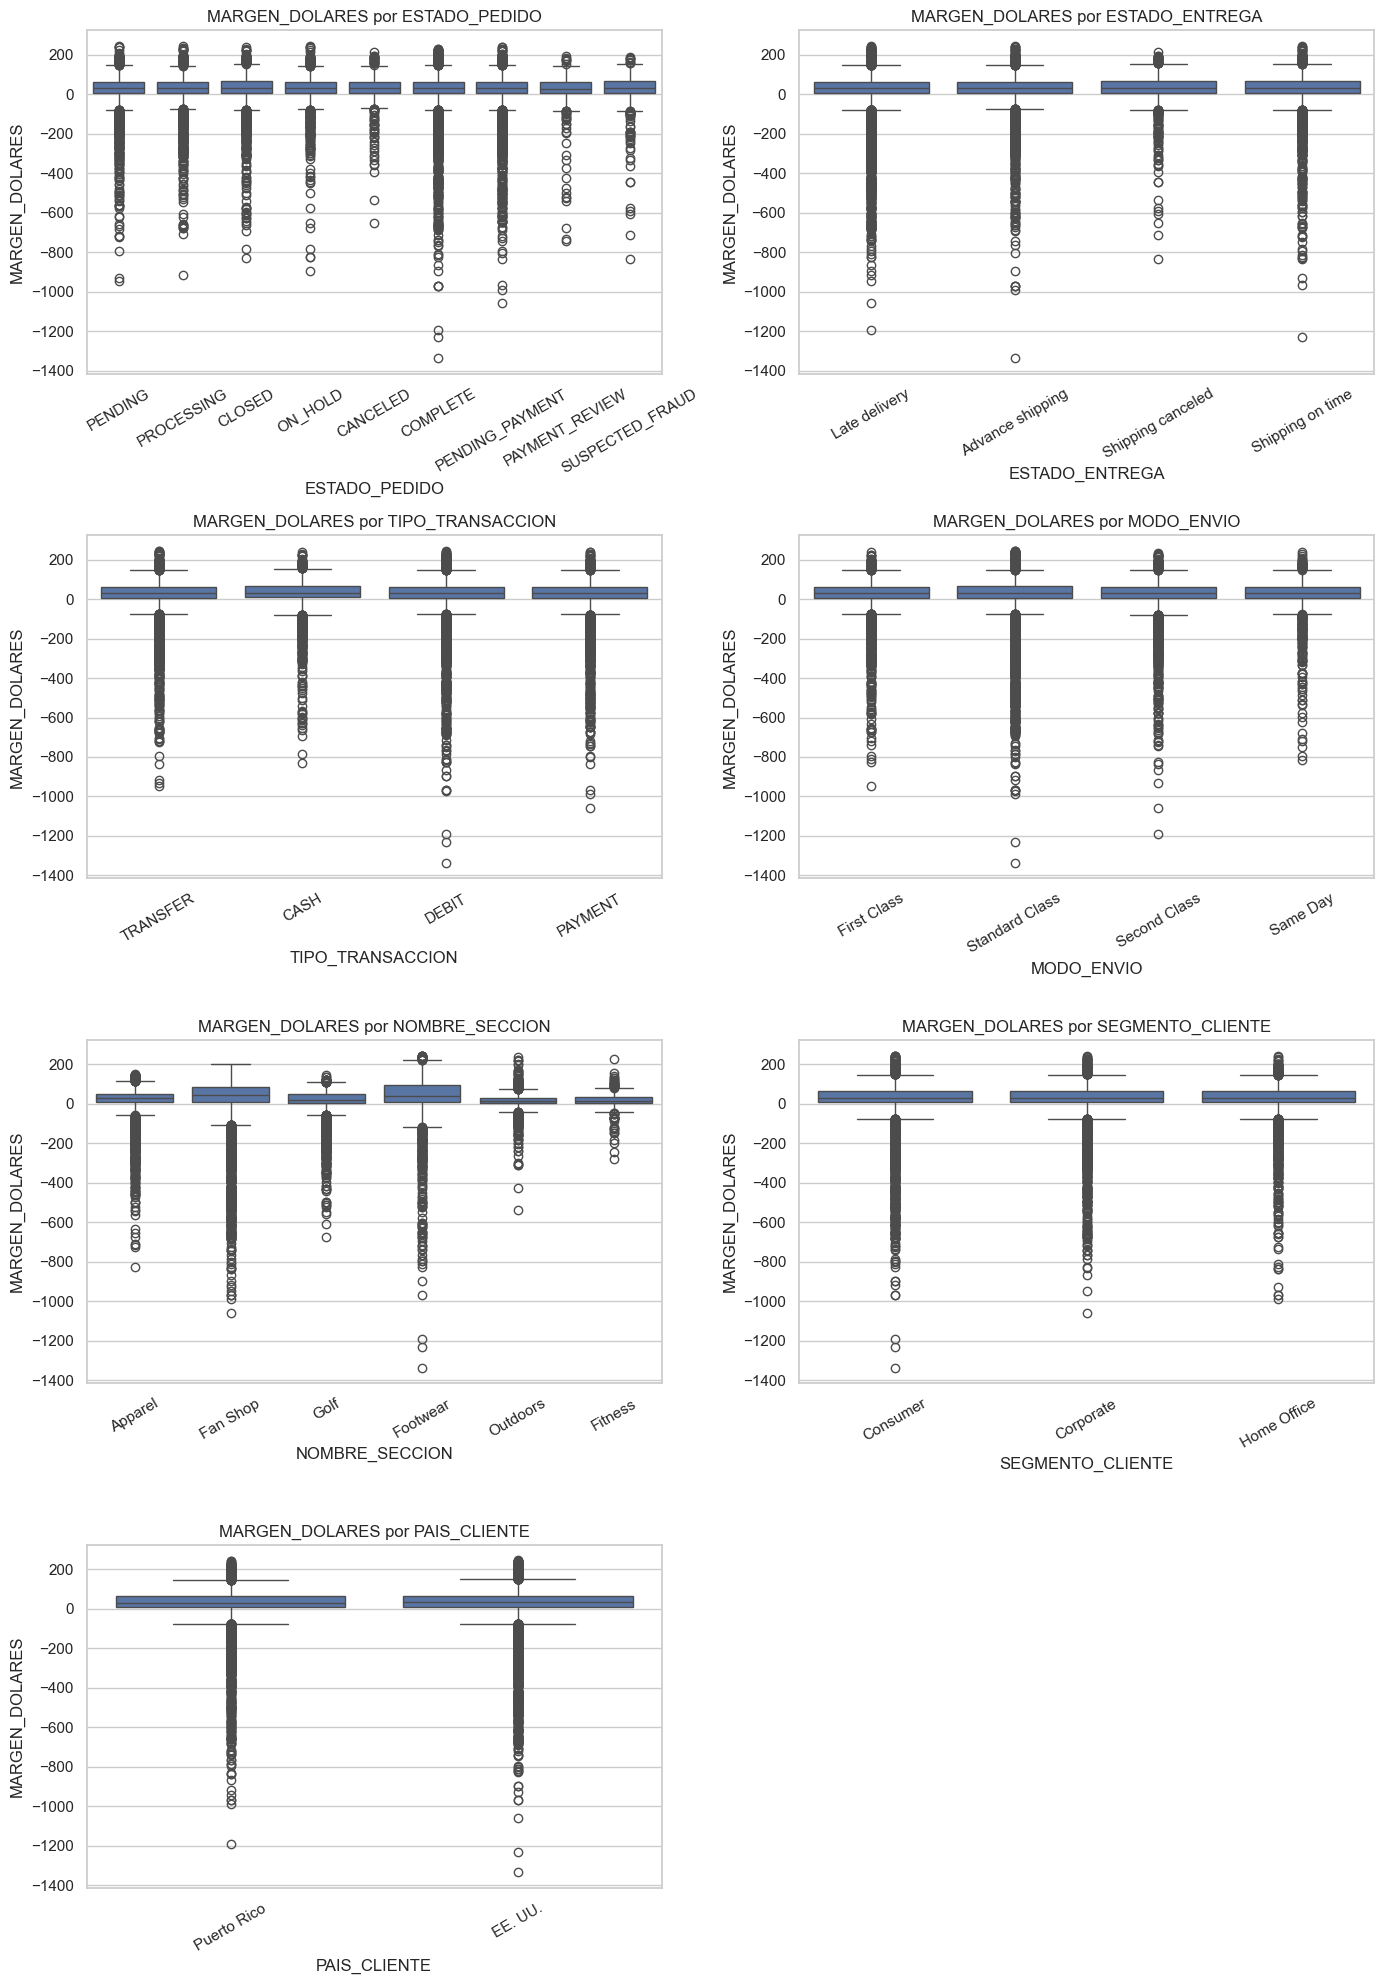

In [178]:

n = len(categoricas_reales)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categoricas_reales):
    sns.boxplot(data=df, x=col, y=target, ax=axes[i])
    axes[i].set_title(f"{target} por {col}")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("output/ej1_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [179]:
# Se observa una alta presencia de valores atípicos en la variable MARGEN_DOLARES, 
# especialmente en la cola negativa. Esto sugiere la existencia de ventas con pérdidas significativas. 
# Dado que estos valores pueden representar situaciones reales del negocio, no se eliminan automáticamente, 
# sino que se consideran parte de la variabilidad del dataset.

In [180]:
outliers_resumen = []

for col in numericas_continuas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mask_outliers = (df[col] < limite_inferior) | (df[col] > limite_superior)
    n_outliers = mask_outliers.sum()
    pct_outliers = mask_outliers.mean() * 100

    outliers_resumen.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "n_outliers": n_outliers,
        "pct_outliers": pct_outliers
    })

outliers_df = pd.DataFrame(outliers_resumen)
outliers_df

,variable,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
0,DIAS_ENVIO_PROGRAMADO,2.000000,4.000000,2.000000,-1.000000,7.000000,0,0.000000
1,DIAS_ENVIO_REAL,2.000000,5.000000,3.000000,-2.500000,9.500000,0,0.000000
2,PRECIO_PRODUCTO,50.000000,199.990005,149.990005,-174.985008,424.975014,0,0.000000
3,CANTIDAD,1.000000,3.000000,2.000000,-2.000000,6.000000,0,0.000000
4,PRECIO_TOTAL_SIN_DESCUENTO,119.980003,299.950012,179.970009,-149.975010,569.905025,0,0.000000
5,TASA_DESCUENTO,0.040000,0.160000,0.120000,-0.140000,0.340000,0,0.000000
6,DESCUENTO,5.500000,28.799999,23.299999,-29.449999,63.749998,1314,4.380000
7,PRECIO_TOTAL_CON_DESCUENTO,105.570000,245.000000,139.430000,-103.575001,454.145000,228,0.760000
8,MARGEN_PORCENTAJE,0.080000,0.360000,0.280000,-0.340000,0.780000,2887,9.623333
9,MARGEN_DOLARES,7.310000,63.750000,56.440000,-77.350000,148.410000,3157,10.523333


In [181]:
for col in categoricas_reales:
    print(f"\n--- {col} ---")
    print("Frecuencia absoluta:")
    print(df[col].value_counts(dropna=False))
    print("\nFrecuencia relativa (%):")
    print(df[col].value_counts(normalize=True, dropna=False) * 100)


--- ESTADO_PEDIDO ---
Frecuencia absoluta:
ESTADO_PEDIDO
COMPLETE           10064
PENDING_PAYMENT     6489
PROCESSING          3562
PENDING             3317
CLOSED              3221
ON_HOLD             1732
SUSPECTED_FRAUD      644
CANCELED             634
PAYMENT_REVIEW       337
Name: count, dtype: int64

Frecuencia relativa (%):
ESTADO_PEDIDO
COMPLETE           33.546667
PENDING_PAYMENT    21.630000
PROCESSING         11.873333
PENDING            11.056667
CLOSED             10.736667
ON_HOLD             5.773333
SUSPECTED_FRAUD     2.146667
CANCELED            2.113333
PAYMENT_REVIEW      1.123333
Name: proportion, dtype: float64

--- ESTADO_ENTREGA ---
Frecuencia absoluta:
ESTADO_ENTREGA
Late delivery        16616
Advance shipping      6845
Shipping on time      5261
Shipping canceled     1278
Name: count, dtype: int64

Frecuencia relativa (%):
ESTADO_ENTREGA
Late delivery        55.386667
Advance shipping     22.816667
Shipping on time     17.536667
Shipping canceled     4.26000

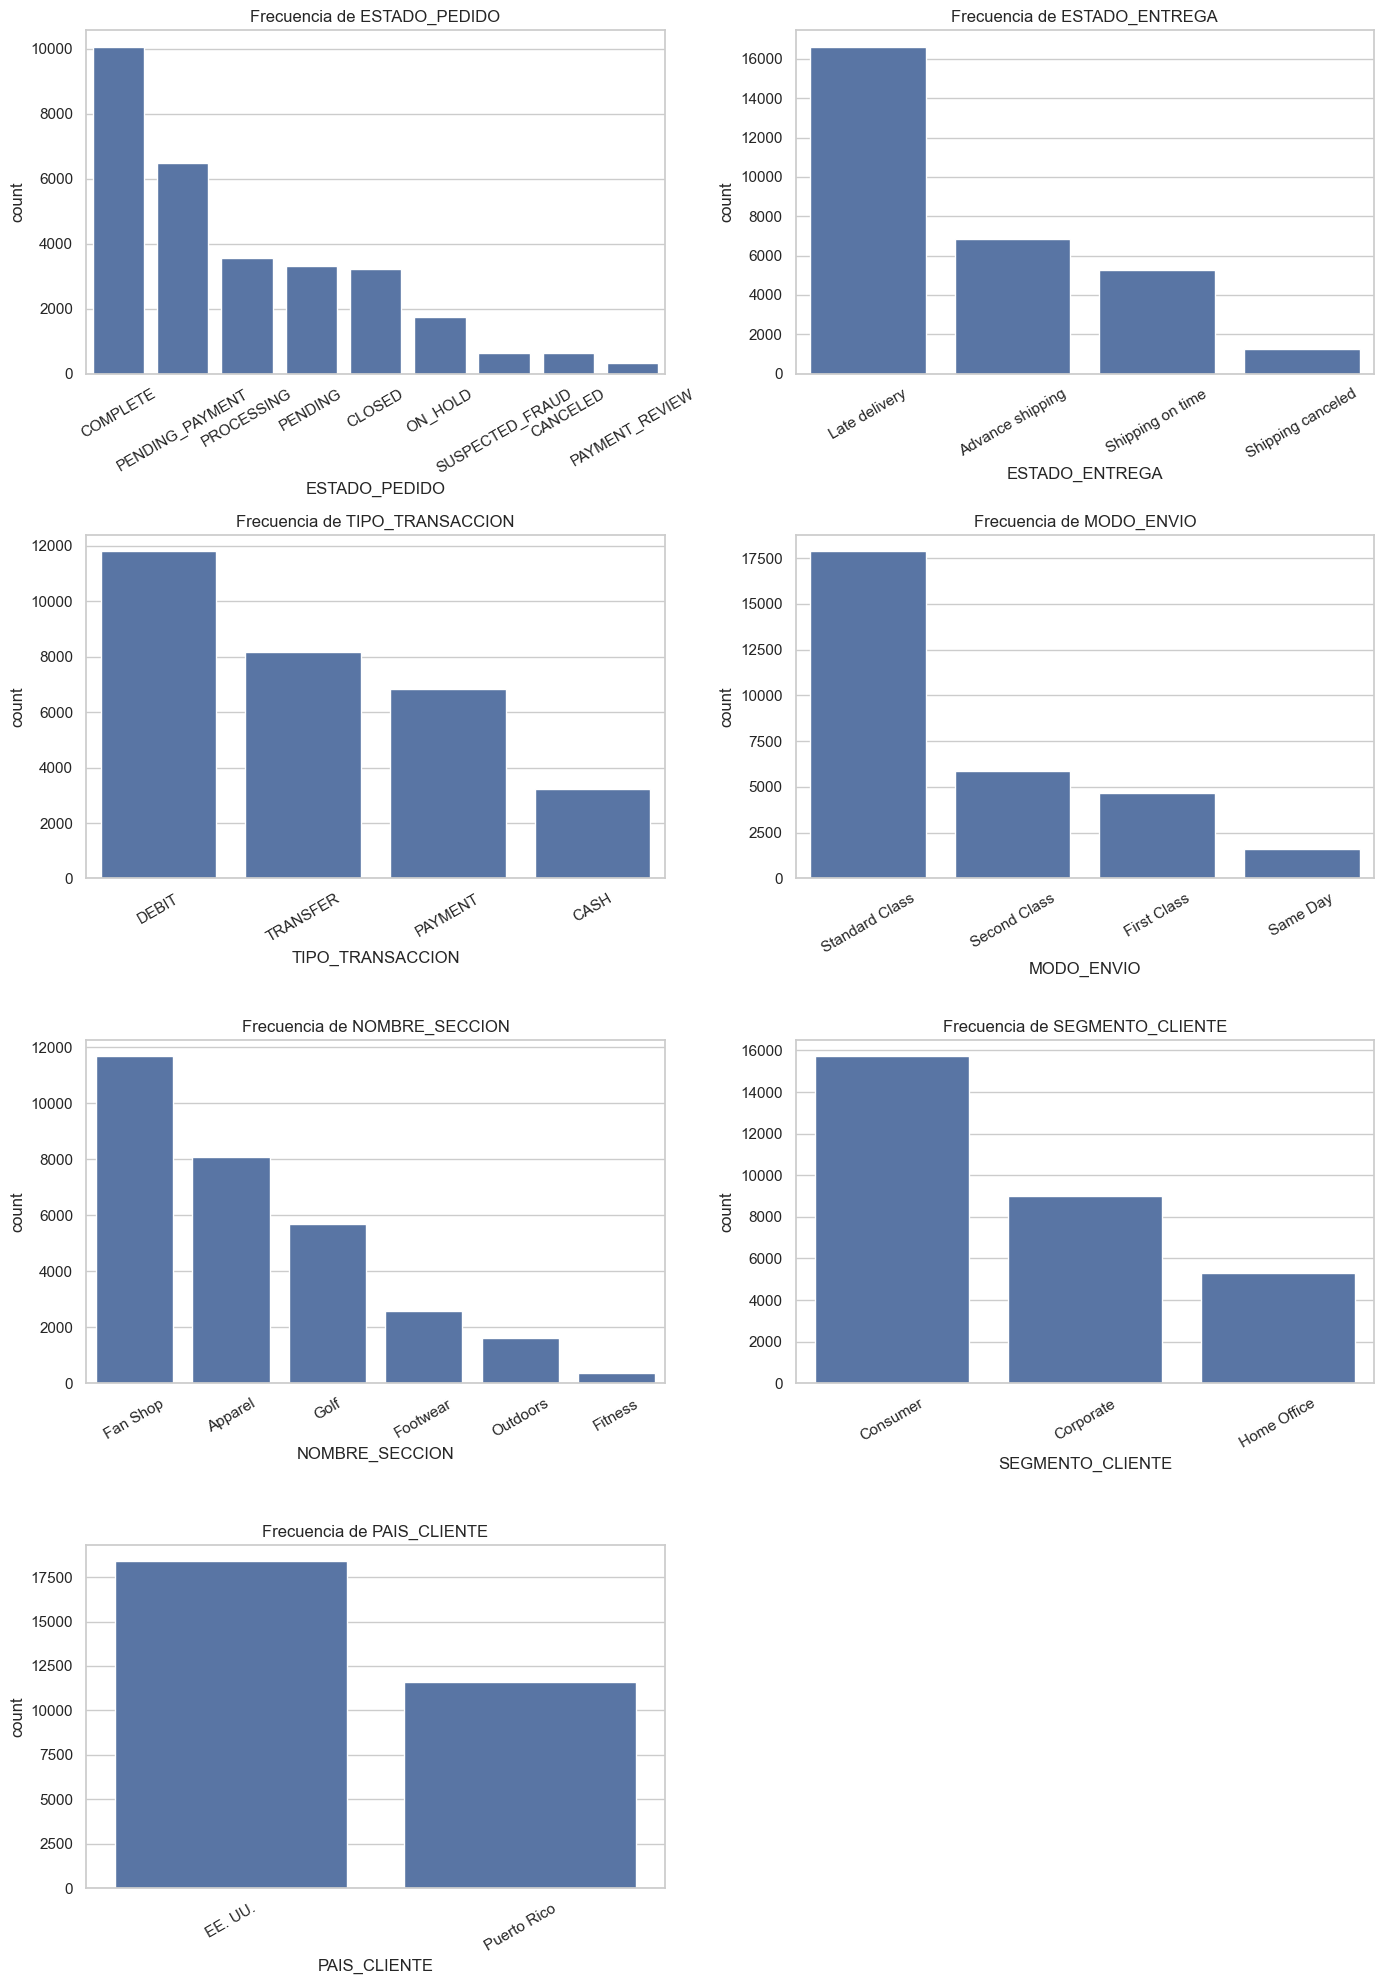

In [182]:
n = len(categoricas_reales)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categoricas_reales):
    orden = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=orden, ax=axes[i])
    axes[i].set_title(f"Frecuencia de {col}")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("output/ej1_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

In [183]:
# Analizamos las correlaciones de las variables numéricas con la variable objetivo MARGEN_DOLARES para identificar cuáles tienen mayor relación lineal, ya sea positiva o negativa, con el margen en dólares.
corr = df[numericas_continuas].corr(method="pearson")
corr

,DIAS_ENVIO_PROGRAMADO,DIAS_ENVIO_REAL,PRECIO_PRODUCTO,CANTIDAD,PRECIO_TOTAL_SIN_DESCUENTO,TASA_DESCUENTO,DESCUENTO,PRECIO_TOTAL_CON_DESCUENTO,MARGEN_PORCENTAJE,MARGEN_DOLARES
DIAS_ENVIO_PROGRAMADO,1.000000,0.520597,0.008437,0.003187,0.011675,0.004826,0.006782,0.011499,0.003728,0.007543
DIAS_ENVIO_REAL,0.520597,1.000000,-0.001993,0.006991,-0.000037,0.001202,-0.002127,0.000367,-0.005318,-0.001022
PRECIO_PRODUCTO,0.008437,-0.001993,1.000000,-0.537772,0.691284,-0.007734,0.386530,0.683736,-0.012555,0.072808
CANTIDAD,0.003187,0.006991,-0.537772,1.000000,0.168425,0.003071,0.102421,0.165006,0.006768,0.028472
PRECIO_TOTAL_SIN_DESCUENTO,0.011675,-0.000037,0.691284,0.168425,1.000000,-0.004996,0.567614,0.987458,-0.008219,0.115822
TASA_DESCUENTO,0.004826,0.001202,-0.007734,0.003071,-0.004996,1.000000,0.714788,-0.142553,-0.002272,-0.019307
DESCUENTO,0.006782,-0.002127,0.386530,0.102421,0.567614,0.714788,1.000000,0.430509,-0.006128,0.048668
PRECIO_TOTAL_CON_DESCUENTO,0.011499,0.000367,0.683736,0.165006,0.987458,-0.142553,0.430509,1.000000,-0.007835,0.117644
MARGEN_PORCENTAJE,0.003728,-0.005318,-0.012555,0.006768,-0.008219,-0.002272,-0.006128,-0.007835,1.000000,0.865146
MARGEN_DOLARES,0.007543,-0.001022,0.072808,0.028472,0.115822,-0.019307,0.048668,0.117644,0.865146,1.000000


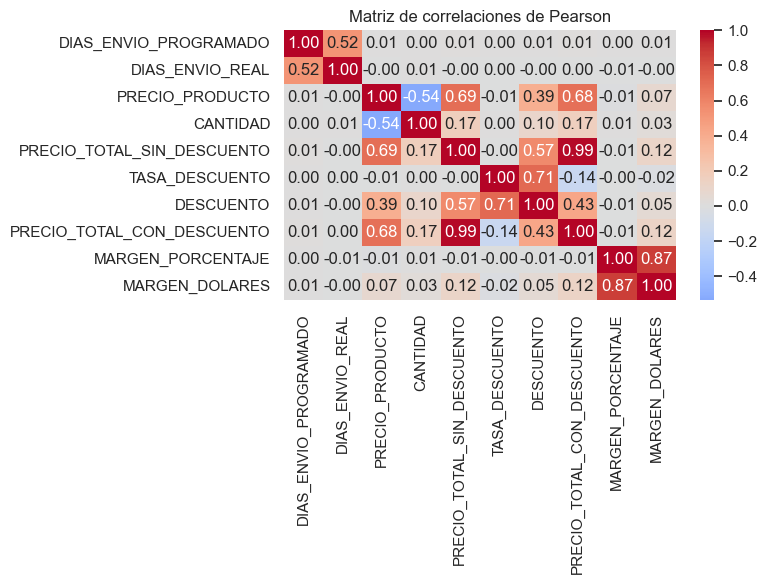

In [184]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlaciones de Pearson")
plt.tight_layout()
plt.savefig("output/ej1_heatmap_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [185]:
# Top 3 relaciones más fuertes (positivas o negativas) con la variable objetivo MARGEN_DOLARES, ordenadas por el valor absoluto de la correlación.
corr_target = corr[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
corr_target.head(3)

MARGEN_PORCENTAJE             0.865146
PRECIO_TOTAL_CON_DESCUENTO    0.117644
PRECIO_TOTAL_SIN_DESCUENTO    0.115822
Name: MARGEN_DOLARES, dtype: float64

In [186]:
# Para identificar pares de variables numéricas que están altamente correlacionadas entre sí (correlación absoluta > 0.9), lo que podría indicar redundancia y la posibilidad de eliminar una de ellas en futuros análisis o modelado.
corr_abs = corr.abs()

pares_altos = []
cols = corr_abs.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if corr_abs.iloc[i, j] > 0.9:
            pares_altos.append((cols[i], cols[j], corr.iloc[i, j]))

pares_altos

[('PRECIO_TOTAL_SIN_DESCUENTO',
  'PRECIO_TOTAL_CON_DESCUENTO',
  np.float64(0.9874575486510652))]

In [187]:
# RESUMEN DEL ANÁLISIS
print("RESUMEN DEL ANÁLISIS")
print("-" * 40)
print("Dimensiones:", df.shape)
print(f"Tamaño en memoria: {memoria_mb:.4f} MB")
print("Target:", target)
print("\nNulos:")
print(tabla_nulos)

print("\nTop 3 correlaciones con el target:")
print(top3)

print("\nOutliers detectados:")
print(outliers_df[["variable", "n_outliers", "pct_outliers"]])

RESUMEN DEL ANÁLISIS
----------------------------------------
Dimensiones: (30000, 31)
Tamaño en memoria: 23.8299 MB
Target: MARGEN_DOLARES

Nulos:
                            nulos_absolutos  nulos_porcentaje
ID_PEDIDO                                 0               0.0
FECHA_PEDIDO                              0               0.0
DIAS_ENVIO_PROGRAMADO                     0               0.0
FECHA_ENVIO                               0               0.0
DIAS_ENVIO_REAL                           0               0.0
RETRASADO                                 0               0.0
ESTADO_PEDIDO                             0               0.0
ESTADO_ENTREGA                            0               0.0
TIPO_TRANSACCION                          0               0.0
MODO_ENVIO                                0               0.0
ID_PRODUCTO                               0               0.0
NOMBRE_PRODUCTO                           0               0.0
PRECIO_PRODUCTO                           0   